In [322]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [323]:
DATA_ROOT = Path("adult")

DIAG_DIR = DATA_ROOT / "phenotype" / "diagnosis"
DEMO_PATH = DATA_ROOT / "phenotype" / "demographics" / "demographics.tsv"
CONFOUNDERS_PATH = DATA_ROOT / "phenotype" / "confounders" / "confounders.tsv"
STATIC_FEATURES_PATH = DATA_ROOT / "features" / "static_features.tsv"
AUDIO_QUALITY_PATH = DATA_ROOT / "features" / "audio_quality_metrics.tsv"
RECORDING_PATH = DATA_ROOT / "phenotype" / "task" / "recording.tsv"

for p in [DIAG_DIR, DEMO_PATH, CONFOUNDERS_PATH, STATIC_FEATURES_PATH, AUDIO_QUALITY_PATH, RECORDING_PATH]:
    print(p, p.exists())

adult/phenotype/diagnosis True
adult/phenotype/demographics/demographics.tsv True
adult/phenotype/confounders/confounders.tsv True
adult/features/static_features.tsv True
adult/features/audio_quality_metrics.tsv False
adult/phenotype/task/recording.tsv True


In [324]:
def read_tsv(path):
    try:
        return pd.read_csv(path, sep="\t", dtype=str, low_memory=False)
    except pd.errors.ParserError:
        return pd.read_csv(path, sep="\t", dtype=str, engine="python", on_bad_lines="skip")


def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def standardize_ids(df):
    df = clean_cols(df)

    rename = {}
    for c in df.columns:
        if c in ["participant", "subject_id", "subject"]:
            rename[c] = "participant_id"
        if c in ["session", "visit_id"]:
            rename[c] = "session_id"
        if c in ["recording", "audio_id", "record_id"]:
            rename[c] = "recording_id"

    return df.rename(columns=rename)


def booleanize(s):
    x = s.astype(str).str.strip().str.lower()

    yes = {"1", "yes", "y", "true", "present", "positive", "diagnosed", "case"}
    no = {"0", "no", "n", "false", "absent", "negative", "control"}

    out = pd.Series(np.nan, index=s.index)

    out[x.isin(yes)] = 1
    out[x.isin(no)] = 0

    numeric = pd.to_numeric(s, errors="coerce")
    out[numeric == 1] = 1
    out[numeric == 0] = 0

    return out

In [325]:
diagnosis_files = sorted(DIAG_DIR.glob("*.tsv"))

print("Diagnosis files:", len(diagnosis_files))
[f.name for f in diagnosis_files]

Diagnosis files: 21


['adhd_adult.tsv',
 'airway_stenosis.tsv',
 'amyotrophic_lateral_sclerosis.tsv',
 'anxiety.tsv',
 'benign_lesions.tsv',
 'bipolar_disorder.tsv',
 'cognitive_impairment.tsv',
 'control.tsv',
 'copd_and_asthma.tsv',
 'depression.tsv',
 'glottic_insufficiency.tsv',
 'laryngeal_cancer.tsv',
 'laryngeal_dystonia.tsv',
 'laryngitis.tsv',
 'muscle_tension_dysphonia.tsv',
 'parkinsons_disease.tsv',
 'precancerous_lesions.tsv',
 'psychiatric_history.tsv',
 'ptsd_adult.tsv',
 'unexplained_chronic_cough.tsv',
 'unilateral_vocal_fold_paralysis.tsv']

In [326]:
diagnosis_tables = []
summary = []

for path in diagnosis_files:
    condition = path.stem
    df = standardize_ids(read_tsv(path))

    if "participant_id" not in df.columns:
        print("Skipping, no participant_id:", path.name)
        continue

    # Most diagnosis files only contain rows when info exists.
    # First pass: assume participant appearing in file = has condition.
    dx_col = f"dx_{condition}"

    df[dx_col] = 1

    pt = (
        df[["participant_id", dx_col]]
        .dropna(subset=["participant_id"])
        .groupby("participant_id", as_index=False)[dx_col]
        .max()
    )

    diagnosis_tables.append(pt)

    summary.append({
        "condition": condition,
        "rows": len(df),
        "positive_participants": pt["participant_id"].nunique()
    })

dx_summary = pd.DataFrame(summary).sort_values("positive_participants", ascending=False)
dx_summary

,condition,rows,positive_participants
0,adhd_adult,173,160
7,control,148,148
1,airway_stenosis,138,138
18,ptsd_adult,141,136
15,parkinsons_disease,106,106
12,laryngeal_dystonia,78,78
17,psychiatric_history,84,75
6,cognitive_impairment,74,74
20,unilateral_vocal_fold_paralysis,69,69
14,muscle_tension_dysphonia,58,58


In [327]:
dx = diagnosis_tables[0]

for table in diagnosis_tables[1:]:
    dx = dx.merge(table, on="participant_id", how="outer")

dx_cols = [c for c in dx.columns if c.startswith("dx_")]
dx[dx_cols] = dx[dx_cols].fillna(0).astype(int)

dx["n_conditions"] = dx[dx_cols].sum(axis=1)

print("Participants:", dx["participant_id"].nunique())
dx.head()

Participants: 832


,participant_id,dx_adhd_adult,dx_airway_stenosis,dx_amyotrophic_lateral_sclerosis,dx_anxiety,dx_benign_lesions,dx_bipolar_disorder,dx_cognitive_impairment,dx_control,dx_copd_and_asthma,...,dx_laryngeal_dystonia,dx_laryngitis,dx_muscle_tension_dysphonia,dx_parkinsons_disease,dx_precancerous_lesions,dx_psychiatric_history,dx_ptsd_adult,dx_unexplained_chronic_cough,dx_unilateral_vocal_fold_paralysis,n_conditions
0,001573,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,002475,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,004119,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,004946,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,005009,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [328]:
pd_col = "dx_parkinsons_disease"

print("Parkinson's column exists:", pd_col in dx.columns)

n_pd = dx[pd_col].sum()
print("Parkinson's participants:", n_pd)

overlaps = []

for c in dx_cols:
    if c == pd_col:
        continue

    overlaps.append({
        "condition": c.replace("dx_", ""),
        "n_condition": dx[c].sum(),
        "n_overlap_with_pd": ((dx[pd_col] == 1) & (dx[c] == 1)).sum(),
        "pct_pd_with_condition": ((dx[pd_col] == 1) & (dx[c] == 1)).sum() / max(n_pd, 1)
    })

pd_overlap = pd.DataFrame(overlaps).sort_values(
    ["n_overlap_with_pd", "n_condition"], ascending=False
)

pd_overlap.head(20)

Parkinson's column exists: True
Parkinson's participants: 106


,condition,n_condition,n_overlap_with_pd,pct_pd_with_condition
0,adhd_adult,160,19,0.179245
16,psychiatric_history,75,14,0.132075
17,ptsd_adult,136,11,0.103774
9,depression,44,4,0.037736
3,anxiety,18,3,0.028302
5,bipolar_disorder,12,3,0.028302
2,amyotrophic_lateral_sclerosis,3,2,0.018868
7,control,148,1,0.009434
6,cognitive_impairment,74,1,0.009434
1,airway_stenosis,138,0,0.000000


In [329]:
LABEL_PRIORITY = [
    "parkinsons_disease",
    "amyotrophic_lateral_sclerosis",
    "cognitive_impairment",
    "depression",
    "anxiety",
    "bipolar_disorder",
    "copd_and_asthma",
    "unexplained_chronic_cough",
    "muscle_tension_dysphonia",
    "glottic_insufficiency",
    "laryngitis",
    "benign_lesions",
    "laryngeal_dystonia",
    "laryngeal_cancer",
    "unilateral_vocal_fold_paralysis",
    "control"
]

def assign_primary_label(row):
    for condition in LABEL_PRIORITY:
        col = f"dx_{condition}"
        if col in row.index and row[col] == 1:
            return condition
    return "other"

dx["primary_label"] = dx.apply(assign_primary_label, axis=1)

dx["primary_label"].value_counts()

primary_label
other                              148
control                            144
parkinsons_disease                 106
laryngeal_dystonia                  78
cognitive_impairment                73
unilateral_vocal_fold_paralysis     66
muscle_tension_dysphonia            56
benign_lesions                      52
unexplained_chronic_cough           39
depression                          35
copd_and_asthma                      9
glottic_insufficiency                8
laryngitis                           6
anxiety                              5
bipolar_disorder                     3
laryngeal_cancer                     3
amyotrophic_lateral_sclerosis        1
Name: count, dtype: int64

In [330]:
features = standardize_ids(read_tsv(STATIC_FEATURES_PATH))

print(features.shape)
features.head()

(32249, 135)


,participant_id,session_id,task_name,transcription,f0semitonefrom27.5hz_sma3nz_amean,f0semitonefrom27.5hz_sma3nz_stddevnorm,f0semitonefrom27.5hz_sma3nz_percentile20.0,f0semitonefrom27.5hz_sma3nz_percentile50.0,f0semitonefrom27.5hz_sma3nz_percentile80.0,f0semitonefrom27.5hz_sma3nz_pctlrange0_2,...,ddp_jitter,local_shimmer,localdb_shimmer,apq3_shimmer,apq5_shimmer,apq11_shimmer,dda_shimmer,stoi,pesq,si_sdr
0,001573,54ab2a33,breath-sounds,.,14.8076810836792,0.09227748960256577,13.726961135864258,14.499690055847168,16.128067016601562,2.4011058807373047,...,0.16977044631165278,0.13242461592977048,1.173990225498671,NaN,NaN,NaN,NaN,0.6214231848716736,1.2163703441619873,-17.089353561401367
1,001573,54ab2a33,diadochokinesis-buttercup,"Buttercup, buttercup, buttercup, buttercup, bu...",35.15102005004883,0.03261668235063553,34.09081268310547,35.23530578613281,36.061866760253906,1.9710540771484375,...,0.03979260396902852,0.10123022388561803,1.0932293467998568,0.028461054239198272,0.04809069513331136,0.12803809913936803,0.08538316271759482,0.9935975074768066,4.104992866516113,20.35997772216797
2,001573,54ab2a33,diadochokinesis-ka,"Caw, caw, caw, caw, caw, caw, caw, caw, caw.",35.402626037597656,0.10043457895517349,35.06975555419922,36.42864227294922,37.597694396972656,2.5279388427734375,...,0.02513657849245054,0.10192386587974862,1.0235033719240014,0.03204122036135194,0.048495640116377935,0.09080770106436131,0.09612366108405582,0.9966703057289124,4.100446701049805,14.955403327941895
3,001573,54ab2a33,diadochokinesis-pa,"Pa, pa, pa, pa, pa, pa, pa, pa, pa, pa.",35.07403564453125,0.10620876401662827,34.9358024597168,36.135677337646484,37.16777420043945,2.2319717407226562,...,0.024216936902650893,0.0944846502041042,1.0701066799529695,0.025309480837110016,0.03798101797687754,0.07684806645859632,0.07592844251133005,0.996798574924469,3.8843941688537598,25.581039428710938
4,001573,54ab2a33,diadochokinesis-pataka,"Pataka, pataka, pataka, pataka, pataka, pataka...",34.61826705932617,0.05029197782278061,33.388912200927734,34.747371673583984,36.142539978027344,2.7536277770996094,...,0.050210778355276625,0.13199846799650605,1.2411549265175204,0.04281566317787977,0.061393997026576316,0.14060690547229704,0.1284469895336393,0.9997990727424622,4.043122291564941,13.203865051269531


In [331]:
df = features.merge(
    dx[["participant_id", "primary_label"] + dx_cols],
    on="participant_id",
    how="inner"
)

print(df.shape)
df["primary_label"].value_counts()

(32213, 157)


primary_label
parkinsons_disease                 5468
control                            5159
other                              4763
cognitive_impairment               3815
laryngeal_dystonia                 2855
unilateral_vocal_fold_paralysis    2443
muscle_tension_dysphonia           2119
benign_lesions                     1972
unexplained_chronic_cough          1233
depression                         1137
glottic_insufficiency               334
copd_and_asthma                     308
laryngitis                          218
anxiety                             150
laryngeal_cancer                    106
bipolar_disorder                     92
amyotrophic_lateral_sclerosis        41
Name: count, dtype: int64

In [332]:
MIN_SAMPLES = 20

valid_labels = df["primary_label"].value_counts()
valid_labels = valid_labels[valid_labels >= MIN_SAMPLES].index.tolist()

df_model = df[df["primary_label"].isin(valid_labels)].copy()

print(df_model["primary_label"].value_counts())

primary_label
parkinsons_disease                 5468
control                            5159
other                              4763
cognitive_impairment               3815
laryngeal_dystonia                 2855
unilateral_vocal_fold_paralysis    2443
muscle_tension_dysphonia           2119
benign_lesions                     1972
unexplained_chronic_cough          1233
depression                         1137
glottic_insufficiency               334
copd_and_asthma                     308
laryngitis                          218
anxiety                             150
laryngeal_cancer                    106
bipolar_disorder                     92
amyotrophic_lateral_sclerosis        41
Name: count, dtype: int64


In [333]:
import pandas as pd

vocal_fold = pd.read_csv(
    'adult/phenotype/diagnosis/unilateral_vocal_fold_paralysis.tsv',
    sep='\t'
)

In [334]:
vocal_fold.columns

Index(['participant_id', 'diagnosis_degree_b', 'diagnosis_degree_b_2',
       'diagnosis_degree_l', 'diagnosis_degree_l_2', 'diagnosis_degree_os',
       'diagnosis_degree_os_2', 'diagnosis_degree_p', 'diagnosis_degree_p_2',
       'diagnosis_degree_r', 'diagnosis_degree_r_2', 'diagnosis_degree_s',
       'diagnosis_degree_s_2', 'diagnosis_uvfp_ds', 'diagnosis_uvfp_treatment',
       'diagnosis_uvfp_dse', 'diagnosis_uvfp_etiology',
       'diagnosis_uvfp_gold_standard_diagnosis', 'diagnosis_uvfp_iatrogenic',
       'diagnosis_uvfp_tumor', 'diagnosis_uvfp_treatment_select___other',
       'diagnosis_uvfp_treatment_select___speech_therapy',
       'diagnosis_uvfp_treatment_select___surgery',
       'diagnosis_uvfp_treatment_surgery___arytenoid_adduction',
       'diagnosis_uvfp_treatment_surgery___other',
       'diagnosis_uvfp_treatment_surgery___thyroplasty',
       'diagnosis_uvfp_treatment_surgery___vocal_fold_injection_augmentation',
       'diagnosis_uvfp_treatment_surgery_thyropla

In [335]:
demographics = pd.read_csv(
    'adult/phenotype/demographics/demographics.tsv',
    sep='\t'
)

In [336]:
demographics

,participant_id,children,cognition,colorblind,country,demographics_duration,demographics_session_id,edu_level,ethnicity,sex_at_birth,...,marital_status___7,race___1,race___2,race___3,race___4,race___5,race___6,race___7,race___8,age
0,5009,No,No,NaN,USA,351.0,db8c326d,College or baccalaureate degree complete,Not Hispanic or Latino,Female,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,83
1,891982,No,No,NaN,USA,432.0,5ba96abe,Associate's or technical degree complete,Not Hispanic or Latino,Male,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,69
2,502326,No,No,NaN,Canada,275.0,9f7a88e1,Graduate or professional degree complete,Not Hispanic or Latino,Male,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,59
3,311375,No,No,NaN,Canada,253.0,cdf2d809,Doctoral or post graduate education,Not Hispanic or Latino,Female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,77
4,356704,No,No,NaN,USA,168.0,9d41b907,College or baccalaureate degree complete,Not Hispanic or Latino,Female,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,707005,No,No,NaN,USA,306.0,829910fd,Doctoral or post graduate education,Not Hispanic or Latino,Female,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,46
907,89022,No,No,NaN,USA,241.0,894a2170,High School or secondary school degree complete,Not Hispanic or Latino,Female,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,53
908,179879,No,No,NaN,USA,185.0,dbc157dc,Some college education,Not Hispanic or Latino,Male,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,44
909,221317,No,Prefer not to answer,NaN,USA,368.0,681e141c,High School or secondary school degree complete,Hispanic or Latino,Female,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,63


In [337]:
# Keep only participant IDs from vocal fold dataset
vf_ids = vocal_fold[['participant_id']].drop_duplicates()

# Merge with demographics
vf_demo = vf_ids.merge(
    demographics,
    on='participant_id',
    how='left'
)

print(vf_demo.columns)

Index(['participant_id', 'children', 'cognition', 'colorblind', 'country',
       'demographics_duration', 'demographics_session_id', 'edu_level',
       'ethnicity', 'sex_at_birth', 'grandparent', 'hearing',
       'household_count', 'household_income_usa', 'housing_status',
       'independent_living', 'live_by_yourself', 'mobility', 'other_live_with',
       'parent', 'primary_transportation', 'roommate', 'self_care',
       'sex_assigned_at_birth', 'sexual_orientation',
       'spouse_partner_sig_other', 'tone_deaf', 'transportation', 'vision',
       'demographics_completed_by___1', 'demographics_completed_by___2',
       'demographics_completed_by___3', 'employ_status___1',
       'employ_status___10', 'employ_status___11', 'employ_status___12',
       'employ_status___13', 'employ_status___2', 'employ_status___3',
       'employ_status___4', 'employ_status___5', 'employ_status___6',
       'employ_status___7', 'employ_status___8', 'employ_status___9',
       'marital_status___1'

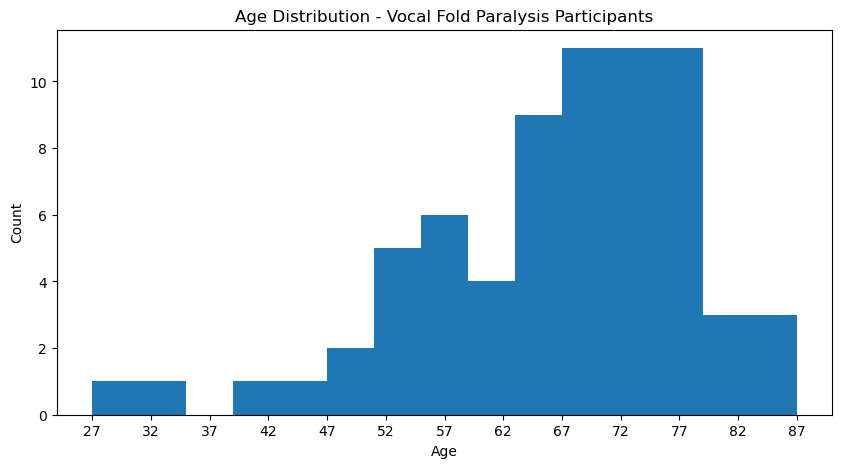

In [338]:
import matplotlib.pyplot as plt
import pandas as pd

vf_demo['age'] = pd.to_numeric(vf_demo['age'], errors='coerce')

ages = vf_demo['age'].dropna()

plt.figure(figsize=(10, 5))

plt.hist(ages, bins=15)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution - Vocal Fold Paralysis Participants')

# Show age labels every 5 years
plt.xticks(
    range(int(ages.min()), int(ages.max()) + 1, 5)
)

plt.show()

In [339]:
vf_demo['age'].describe()

count    69.000000
mean     65.956522
std      11.624562
min      27.000000
25%      59.000000
50%      68.000000
75%      74.000000
max      87.000000
Name: age, dtype: float64

In [340]:
import pandas as pd
import matplotlib.pyplot as plt

# Load control participants
controls = pd.read_csv(
    'adult/phenotype/diagnosis/control.tsv',
    sep='\t'
)

# Load demographics
demographics = pd.read_csv(
    'adult/phenotype/demographics/demographics.tsv',
    sep='\t'
)

# Keep unique participant IDs
control_ids = controls[['participant_id']].drop_duplicates()

# Merge with demographics
control_demo = control_ids.merge(
    demographics,
    on='participant_id',
    how='left'
)

# Find age column
print([c for c in control_demo.columns if 'age' in c.lower()])

['age']


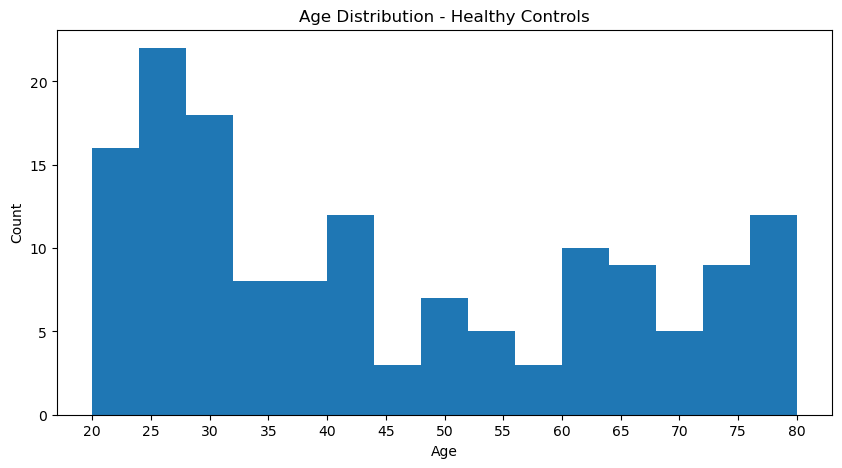

In [341]:
control_demo['age'] = pd.to_numeric(
    control_demo['age'],
    errors='coerce'
)

ages = control_demo['age'].dropna()

plt.figure(figsize=(10, 5))

plt.hist(ages, bins=15)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution - Healthy Controls')

plt.xticks(
    range(int(ages.min()), int(ages.max()) + 1, 5)
)

plt.show()

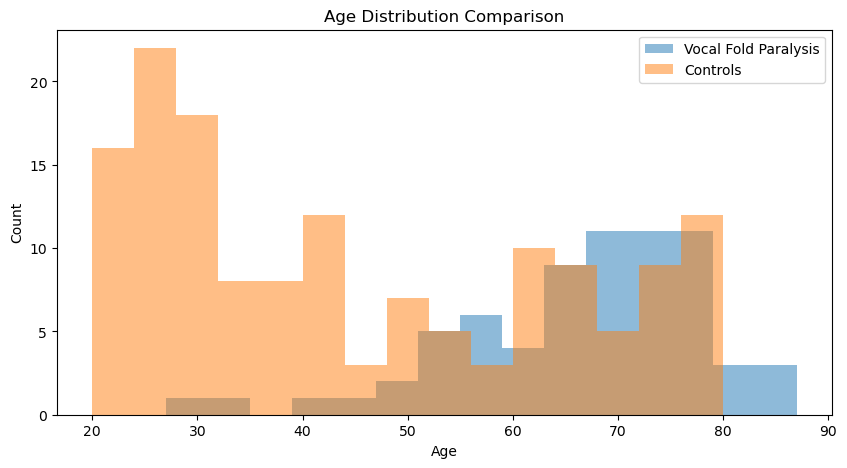

In [342]:
plt.figure(figsize=(10, 5))

plt.hist(vf_demo['age'].dropna(), bins=15, alpha=0.5, label='Vocal Fold Paralysis')
plt.hist(control_demo['age'].dropna(), bins=15, alpha=0.5, label='Controls')

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution Comparison')

plt.legend()

plt.show()

In [343]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get ages
vf_ages = vf_demo['age'].dropna()
control_ages = control_demo['age'].dropna()

# Define common bins
bins = np.arange(
    min(vf_ages.min(), control_ages.min()),
    max(vf_ages.max(), control_ages.max()) + 5,
    5
)

# Histogram counts
vf_counts, edges = np.histogram(vf_ages, bins=bins)
control_counts, _ = np.histogram(control_ages, bins=bins)

# Overlap score = minimum count in each bin
overlap = np.minimum(vf_counts, control_counts)

# Create dataframe for inspection
overlap_df = pd.DataFrame({
    'bin_start': edges[:-1],
    'bin_end': edges[1:],
    'vf_count': vf_counts,
    'control_count': control_counts,
    'overlap_score': overlap
})

print(overlap_df.sort_values(
    'overlap_score',
    ascending=False
))

    bin_start  bin_end  vf_count  control_count  overlap_score
11       75.0     80.0        13             15             13
9        65.0     70.0        12              7              7
10       70.0     75.0        15              7              7
6        50.0     55.0         6              6              6
8        60.0     65.0         6             14              6
7        55.0     60.0         8              4              4
5        45.0     50.0         2              7              2
12       80.0     85.0         2              2              2
1        25.0     30.0         1             27              1
2        30.0     35.0         1             11              1
4        40.0     45.0         1             13              1
0        20.0     25.0         0             23              0
3        35.0     40.0         0             11              0
13       85.0     90.0         2              0              0


In [344]:
MIN_AGE = 60
MAX_AGE = 80

vf_filtered = vf_demo[
    (vf_demo['age'] >= MIN_AGE) &
    (vf_demo['age'] <= MAX_AGE)
]

control_filtered = control_demo[
    (control_demo['age'] >= MIN_AGE) &
    (control_demo['age'] <= MAX_AGE)
]

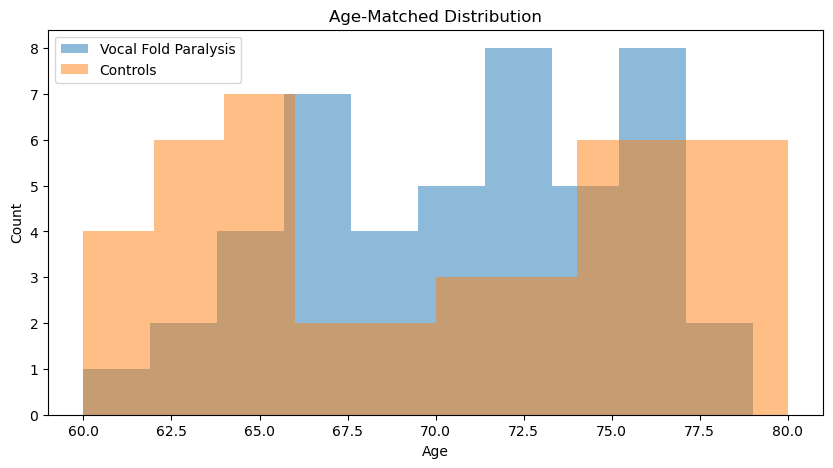

In [345]:
plt.figure(figsize=(10,5))

plt.hist(
    vf_filtered['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='Vocal Fold Paralysis'
)

plt.hist(
    control_filtered['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='Controls'
)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age-Matched Distribution')

plt.legend()

plt.show()

In [346]:
import matplotlib.pyplot as plt

# Check gender column names first
print([c for c in vf_filtered.columns if 'sex' in c.lower() or 'gender' in c.lower()])

['sex_at_birth', 'sex_assigned_at_birth', 'sexual_orientation']


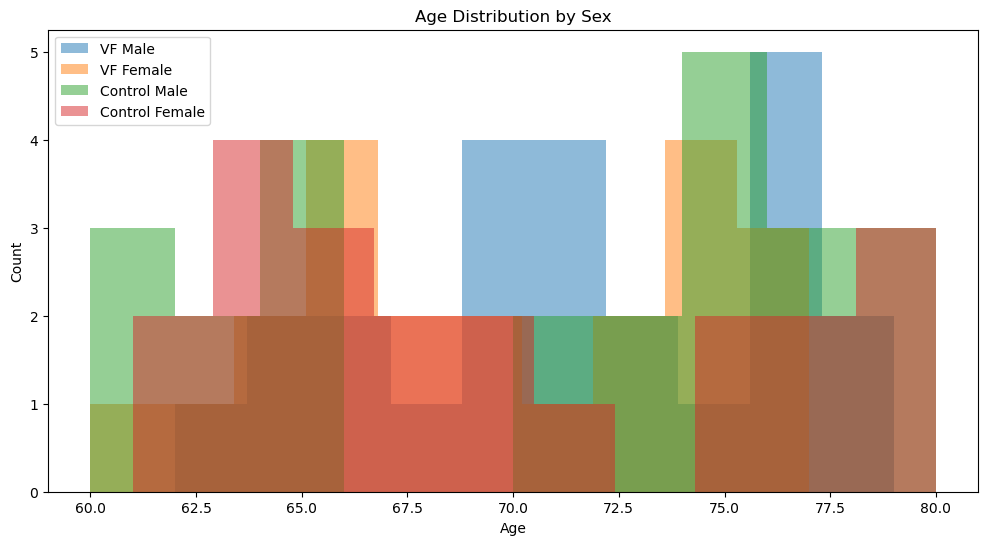

In [347]:
# Split by sex
vf_male = vf_filtered[vf_filtered['sex_at_birth'] == 'Male']
vf_female = vf_filtered[vf_filtered['sex_at_birth'] == 'Female']

control_male = control_filtered[control_filtered['sex_at_birth'] == 'Male']
control_female = control_filtered[control_filtered['sex_at_birth'] == 'Female']

# Plot
plt.figure(figsize=(12,6))

plt.hist(
    vf_male['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='VF Male'
)

plt.hist(
    vf_female['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='VF Female'
)

plt.hist(
    control_male['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='Control Male'
)

plt.hist(
    control_female['age'].dropna(),
    bins=10,
    alpha=0.5,
    label='Control Female'
)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Sex')

plt.legend()

plt.show()

In [348]:
static_features = pd.read_csv(
    'adult/features/static_features.tsv',
    sep='\t'
)

In [349]:
print(static_features["participant_id"].head())
print(next(iter(vf_ids)))
print(next(iter(control_ids)))

0    1573
1    1573
2    1573
3    1573
4    1573
Name: participant_id, dtype: int64
participant_id
participant_id


In [350]:
print(static_features["participant_id"].dtype)
print(type(next(iter(vf_ids))))

int64
<class 'str'>


In [351]:
static_features["participant_id"] = (
    static_features["participant_id"]
    .astype(str)
    .str.strip()
)

vf_ids = {
    str(x).strip()
    for x in vf_filtered["participant_id"].dropna().unique()
}

control_ids = {
    str(x).strip()
    for x in control_filtered["participant_id"].dropna().unique()
}

In [352]:
print(
    static_features["participant_id"].isin(vf_ids).sum()
)

print(
    static_features["participant_id"].isin(control_ids).sum()
)

1711
1589


In [353]:
# static_features['group'] = None

# static_features.loc[
#     static_features['participant_id'].isin(vf_ids),
#     'group'
# ] = 'vf'

# static_features.loc[
#     static_features['participant_id'].isin(control_ids),
#     'group'
# ] = 'control'

# analysis_df = static_features.dropna(subset=['group']).copy()

# analysis_df['group'].value_counts()

In [354]:
static_features = static_features.copy()

static_features["group"] = "other"

static_features.loc[
    static_features["participant_id"].isin(vf_ids),
    "group"
] = "vf"

static_features.loc[
    static_features["participant_id"].isin(control_ids),
    "group"
] = "control"

print(static_features["group"].value_counts())

analysis_df = static_features[
    static_features["group"].isin(["vf", "control"])
].copy()

print(analysis_df["group"].value_counts())
print(analysis_df.shape)

group
other      28949
vf          1711
control     1589
Name: count, dtype: int64
group
vf         1711
control    1589
Name: count, dtype: int64
(3300, 136)


In [355]:
analysis_df

,participant_id,session_id,task_name,transcription,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,local_shimmer,localDB_shimmer,apq3_shimmer,apq5_shimmer,apq11_shimmer,dda_shimmer,stoi,pesq,si_sdr,group
103,4946,e99d1c27,cape-v-sentences-1,The blue spot is on the key again.,31.950283,0.095882,29.224007,32.443958,34.984173,5.760166,...,0.111955,1.053939,0.044066,0.066014,0.122866,0.132197,0.897591,1.754591,15.312733,vf
104,4946,e99d1c27,cape-v-sentences-2,How hard did he hit him?,31.617601,0.112548,28.693310,32.776379,34.700371,6.007061,...,0.131175,1.327571,0.059021,0.081377,0.137211,0.177063,0.964593,2.307719,20.860464,vf
105,4946,e99d1c27,cape-v-sentences-3,We were away a year ago.,32.666248,0.072953,30.595016,33.327095,35.010300,4.415283,...,0.128261,1.279255,0.058199,0.079240,0.121518,0.174597,0.943645,2.148289,18.720102,vf
106,4946,e99d1c27,cape-v-sentences-4,We eat eggs every Easter.,33.140198,0.077334,30.986834,33.965096,35.297749,4.310915,...,0.143739,1.321250,0.064678,0.084649,0.138328,0.194033,0.988117,3.049033,23.281939,vf
107,4946,e99d1c27,cape-v-sentences-5,My mama makes lemon muffins.,32.870804,0.070541,31.584854,33.279552,34.789062,3.204208,...,0.120961,1.158418,0.054889,0.082032,0.129617,0.164668,0.783337,1.214922,6.956131,vf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32169,998165,76207087,respiration-and-cough-fivebreaths-4,.,29.192017,0.016073,28.924072,29.147495,29.736162,0.812090,...,0.210929,1.787841,0.094531,0.118694,0.183059,0.283592,0.421697,1.168506,-15.041073,control
32170,998165,76207087,respiration-and-cough-threequickbreaths-1,Ah,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.471435,1.163834,-14.631231,control
32171,998165,76207087,respiration-and-cough-threequickbreaths-2,Huuuuh Huuuuh Huuuuh Huuuuh Huuuuh,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.236258,1.853471,0.138271,NaN,NaN,0.414812,0.432561,1.117017,-14.876136,control
32172,998165,76207087,story-recall,You wanted to know more about my 93 year old g...,30.437565,0.094332,28.754066,30.377649,32.186901,3.432835,...,0.070339,0.715409,0.022952,0.033329,0.069791,0.068857,0.995290,2.896439,17.114597,control


## Filter by task

In [356]:
recording = pd.read_csv(
    "adult/phenotype/task/recording.tsv",
    sep="\t"
)

acoustic_task = pd.read_csv(
    "adult/phenotype/task/acoustic_task.tsv",
    sep="\t"
)

recording_tasks = recording.merge(
    acoustic_task,
    left_on="recording_acoustic_task_id",
    right_on="acoustic_task_id",
    how="left",
    suffixes=("_recording", "_task")
)

recording_tasks["acoustic_task_name"].value_counts().head(50)

acoustic_task_name
respiration-and-cough        8148
diadochokinesis              4110
free-speech                  2832
maximum-phonation-time       2475
cape-v-sentences             2184
glides                       1794
productive-vocabulary        1578
harvard-sentences            1480
prolonged-vowel               899
picture-description           892
rainbow-passage               823
loudness                      822
story-recall                  819
caterpillar-passage           384
diadochokinesis-v2            365
respiration-and-cough-v2      365
voluntary-cough               309
breath-sounds                 308
word-color-stroop             261
random-item-generation        236
cinderella-story              235
free-speech-v2                222
open-response-questions       164
animal-fluency                163
cape-v-sentences-v2           120
maximum-phonation-time-v2      89
loudness-v2                    75
story-recall-v2                73
random-item-generation-v2    

In [357]:
analysis_df

,participant_id,session_id,task_name,transcription,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,local_shimmer,localDB_shimmer,apq3_shimmer,apq5_shimmer,apq11_shimmer,dda_shimmer,stoi,pesq,si_sdr,group
103,4946,e99d1c27,cape-v-sentences-1,The blue spot is on the key again.,31.950283,0.095882,29.224007,32.443958,34.984173,5.760166,...,0.111955,1.053939,0.044066,0.066014,0.122866,0.132197,0.897591,1.754591,15.312733,vf
104,4946,e99d1c27,cape-v-sentences-2,How hard did he hit him?,31.617601,0.112548,28.693310,32.776379,34.700371,6.007061,...,0.131175,1.327571,0.059021,0.081377,0.137211,0.177063,0.964593,2.307719,20.860464,vf
105,4946,e99d1c27,cape-v-sentences-3,We were away a year ago.,32.666248,0.072953,30.595016,33.327095,35.010300,4.415283,...,0.128261,1.279255,0.058199,0.079240,0.121518,0.174597,0.943645,2.148289,18.720102,vf
106,4946,e99d1c27,cape-v-sentences-4,We eat eggs every Easter.,33.140198,0.077334,30.986834,33.965096,35.297749,4.310915,...,0.143739,1.321250,0.064678,0.084649,0.138328,0.194033,0.988117,3.049033,23.281939,vf
107,4946,e99d1c27,cape-v-sentences-5,My mama makes lemon muffins.,32.870804,0.070541,31.584854,33.279552,34.789062,3.204208,...,0.120961,1.158418,0.054889,0.082032,0.129617,0.164668,0.783337,1.214922,6.956131,vf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32169,998165,76207087,respiration-and-cough-fivebreaths-4,.,29.192017,0.016073,28.924072,29.147495,29.736162,0.812090,...,0.210929,1.787841,0.094531,0.118694,0.183059,0.283592,0.421697,1.168506,-15.041073,control
32170,998165,76207087,respiration-and-cough-threequickbreaths-1,Ah,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.471435,1.163834,-14.631231,control
32171,998165,76207087,respiration-and-cough-threequickbreaths-2,Huuuuh Huuuuh Huuuuh Huuuuh Huuuuh,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.236258,1.853471,0.138271,NaN,NaN,0.414812,0.432561,1.117017,-14.876136,control
32172,998165,76207087,story-recall,You wanted to know more about my 93 year old g...,30.437565,0.094332,28.754066,30.377649,32.186901,3.432835,...,0.070339,0.715409,0.022952,0.033329,0.069791,0.068857,0.995290,2.896439,17.114597,control


In [358]:
for t in sorted(analysis_df["task_name"].dropna().astype(str).unique()):
    print(repr(t))

'animal-fluency'
'breath-sounds'
'cape-v-sentences-1'
'cape-v-sentences-2'
'cape-v-sentences-3'
'cape-v-sentences-4'
'cape-v-sentences-5'
'cape-v-sentences-6'
'cape-v-sentences-v2-1'
'cape-v-sentences-v2-2'
'cape-v-sentences-v2-3'
'cape-v-sentences-v2-4'
'cape-v-sentences-v2-5'
'cape-v-sentences-v2-6'
'caterpillar-passage'
'cinderella-story'
'diadochokinesis-buttercup'
'diadochokinesis-ka'
'diadochokinesis-pa'
'diadochokinesis-pataka'
'diadochokinesis-ta'
'diadochokinesis-v2-buttercup'
'diadochokinesis-v2-kuh'
'diadochokinesis-v2-puh'
'diadochokinesis-v2-puhtuhkuh'
'diadochokinesis-v2-tuh'
'free-speech'
'free-speech-1'
'free-speech-2'
'free-speech-3'
'free-speech-v2-1'
'free-speech-v2-2'
'free-speech-v2-3'
'glides-high-to-low'
'glides-low-to-high'
'harvard-sentences-list-22-1'
'harvard-sentences-list-22-10'
'harvard-sentences-list-22-2'
'harvard-sentences-list-22-3'
'harvard-sentences-list-22-4'
'harvard-sentences-list-22-5'
'harvard-sentences-list-22-6'
'harvard-sentences-list-22-7'
'

In [359]:
selected_tasks = [
    "maximum-phonation-time",
    "prolonged-vowel",
    "rainbow-passage"
]

In [360]:
analysis_task_df = analysis_df[
    analysis_df["task_name"].isin(selected_tasks)
].copy()

analysis_task_df["task_name"].value_counts()
analysis_task_df["group"].value_counts()

group
vf         94
control    85
Name: count, dtype: int64

In [361]:
# First inspect exact task names
analysis_task_df["task_name"].value_counts().head(50)

task_name
prolonged-vowel    92
rainbow-passage    87
Name: count, dtype: int64

In [362]:
analysis_df.columns

Index(['participant_id', 'session_id', 'task_name', 'transcription',
       'F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       ...
       'local_shimmer', 'localDB_shimmer', 'apq3_shimmer', 'apq5_shimmer',
       'apq11_shimmer', 'dda_shimmer', 'stoi', 'pesq', 'si_sdr', 'group'],
      dtype='str', length=136)

In [363]:
analysis_df = analysis_task_df.copy()

In [364]:
print("Tasks:")
print(analysis_task_df["task_name"].value_counts())

print("\nGroups:")
print(analysis_task_df["group"].value_counts())

print("\nNumeric columns:")
print(analysis_task_df.select_dtypes(include=np.number).shape)

Tasks:
task_name
prolonged-vowel    92
rainbow-passage    87
Name: count, dtype: int64

Groups:
group
vf         94
control    85
Name: count, dtype: int64

Numeric columns:
(179, 131)


In [365]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

results = []

numeric_cols = analysis_task_df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    vf_vals = analysis_task_df[
        analysis_task_df['group'] == 'vf'
    ][col].dropna()

    control_vals = analysis_task_df[
        analysis_task_df['group'] == 'control'
    ][col].dropna()

    if len(vf_vals) > 5 and len(control_vals) > 5:

        tstat, pval = ttest_ind(
            vf_vals,
            control_vals,
            equal_var=False
        )

        pooled_std = np.sqrt(
            (
                vf_vals.var() +
                control_vals.var()
            ) / 2
        )

        if pooled_std > 0:
            effect_size = (
                vf_vals.mean() -
                control_vals.mean()
            ) / pooled_std
        else:
            effect_size = 0

        results.append([
            col,
            pval,
            effect_size,
            vf_vals.mean(),
            control_vals.mean()
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'feature',
        'p_value',
        'effect_size',
        'vf_mean',
        'control_mean'
    ]
)

results_df = results_df.sort_values(
    'effect_size',
    key=np.abs,
    ascending=False
)

results_df.head(30)

,feature,p_value,effect_size,vf_mean,control_mean
103,cepstral_peak_prominence_mean,5.347698e-08,-0.846356,8.882026,11.200094
30,jitterLocal_sma3nz_amean,7.905718e-08,0.833862,0.024502,0.015032
40,F1frequency_sma3nz_amean,1.553889e-07,0.813754,676.528009,595.380160
68,mfcc1V_sma3nz_amean,6.063195e-07,-0.771805,28.702048,34.494195
46,F2frequency_sma3nz_amean,2.238669e-06,0.730131,1701.785978,1598.520419
104,cepstral_peak_prominence_std,3.759232e-06,-0.719321,1.592874,2.378411
44,F1amplitudeLogRelF0_sma3nz_amean,6.655602e-06,-0.691774,-124.019104,-98.461777
124,apq3_shimmer,9.018758e-06,0.679341,0.050990,0.034058
127,dda_shimmer,9.018758e-06,0.679341,0.152971,0.102175
22,mfcc1_sma3_amean,1.650556e-05,-0.663784,20.923204,25.382499


## Fingerprint

In [366]:
keywords = [
    "jitter", "shimmer", "hnr", "harmonic", "noise",
    "periodicity", "pitch", "f0", "loudness",
    "cpp", "cepstral", "spectral", "slope", "voice"
]

In [367]:
import pandas as pd
import numpy as np

static_features = pd.read_csv(
    "adult/features/static_features.tsv",
    sep="\t"
)

vf_ids = set(vf_filtered["participant_id"])
control_ids = set(control_filtered["participant_id"])

static_features["group"] = None

static_features.loc[
    static_features["participant_id"].isin(vf_ids),
    "group"
] = "vocal_fold_paralysis"

static_features.loc[
    static_features["participant_id"].isin(control_ids),
    "group"
] = "control"

analysis_df = static_features[
    static_features["group"].isin(["vocal_fold_paralysis", "control"])
].copy()

analysis_df["group"].value_counts()

group
vocal_fold_paralysis    1711
control                 1589
Name: count, dtype: int64

In [368]:
numeric_cols = analysis_df.select_dtypes(include="number").columns.tolist()

candidate_features = [
    c for c in numeric_cols
    if any(k in c.lower() for k in keywords)
]

len(candidate_features), candidate_features[:30]

(76,
 ['F0semitoneFrom27.5Hz_sma3nz_amean',
  'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
  'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
  'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
  'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
  'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
  'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
  'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
  'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
  'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope',
  'loudness_sma3_amean',
  'loudness_sma3_stddevNorm',
  'loudness_sma3_percentile20.0',
  'loudness_sma3_percentile50.0',
  'loudness_sma3_percentile80.0',
  'loudness_sma3_pctlrange0-2',
  'loudness_sma3_meanRisingSlope',
  'loudness_sma3_stddevRisingSlope',
  'loudness_sma3_meanFallingSlope',
  'loudness_sma3_stddevFallingSlope',
  'spectralFlux_sma3_amean',
  'spectralFlux_sma3_stddevNorm',
  'jitterLocal_sma3nz_amean',
  'jitterLocal_sma3nz_stddevNorm',
  'shimmerLocaldB_sma3nz_amean',
  'shimmerLocaldB_sma3nz

In [369]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

rows = []

for feature in candidate_features:
    vf_vals = analysis_df.loc[
        analysis_df["group"] == "vocal_fold_paralysis",
        feature
    ].dropna()

    ctrl_vals = analysis_df.loc[
        analysis_df["group"] == "control",
        feature
    ].dropna()

    if len(vf_vals) < 10 or len(ctrl_vals) < 10:
        continue

    t_stat, p_val = ttest_ind(vf_vals, ctrl_vals, equal_var=False)

    pooled_std = np.sqrt((vf_vals.var() + ctrl_vals.var()) / 2)

    if pooled_std == 0 or np.isnan(pooled_std):
        continue

    cohen_d = (vf_vals.mean() - ctrl_vals.mean()) / pooled_std

    rows.append({
        "feature": feature,
        "vf_mean": vf_vals.mean(),
        "control_mean": ctrl_vals.mean(),
        "difference": vf_vals.mean() - ctrl_vals.mean(),
        "cohen_d": cohen_d,
        "abs_cohen_d": abs(cohen_d),
        "p_value": p_val,
        "vf_n": len(vf_vals),
        "control_n": len(ctrl_vals)
    })

fingerprint_df = pd.DataFrame(rows)

fingerprint_df["fdr_p"] = multipletests(
    fingerprint_df["p_value"],
    method="fdr_bh"
)[1]

fingerprint_df = fingerprint_df.sort_values(
    "abs_cohen_d",
    ascending=False
)

fingerprint_df.head(30)

,feature,vf_mean,control_mean,difference,cohen_d,abs_cohen_d,p_value,vf_n,control_n,fdr_p
59,cepstral_peak_prominence_mean,7.902783,9.521323,-1.618540,-0.488935,0.488935,7.227152e-42,1641,1547,5.492635e-40
60,cepstral_peak_prominence_std,1.375041,1.820898,-0.445857,-0.376080,0.376080,8.994939e-26,1641,1547,3.418077e-24
57,spectral_slope,-15.113069,-17.181082,2.068013,0.353833,0.353833,3.353578e-23,1668,1550,8.495732e-22
75,dda_shimmer,0.178664,0.147451,0.031214,0.322265,0.322265,2.242678e-19,1634,1528,3.408870e-18
72,apq3_shimmer,0.059555,0.049150,0.010405,0.322265,0.322265,2.242678e-19,1634,1528,3.408870e-18
32,F1amplitudeLogRelF0_sma3nz_amean,-151.392347,-138.049069,-13.343278,-0.274972,0.274972,4.525082e-15,1711,1589,5.731770e-14
35,F2amplitudeLogRelF0_sma3nz_stddevNorm,-0.466527,-0.591034,0.124507,0.273474,0.273474,8.228770e-15,1711,1589,8.934093e-14
71,localDB_shimmer,1.204452,1.079740,0.124712,0.259152,0.259152,3.147773e-13,1653,1545,2.990384e-12
70,local_shimmer,0.132819,0.117068,0.015750,0.256399,0.256399,5.392661e-13,1653,1545,4.098423e-12
25,shimmerLocaldB_sma3nz_stddevNorm,0.592513,0.689818,-0.097305,-0.253165,0.253165,4.911098e-13,1711,1589,4.098423e-12


In [370]:
top_fingerprint = fingerprint_df[
    (fingerprint_df["fdr_p"] < 0.05) &
    (fingerprint_df["abs_cohen_d"] >= 0.2)
].copy()

top_fingerprint.head(25)

,feature,vf_mean,control_mean,difference,cohen_d,abs_cohen_d,p_value,vf_n,control_n,fdr_p
59,cepstral_peak_prominence_mean,7.902783,9.521323,-1.618540,-0.488935,0.488935,7.227152e-42,1641,1547,5.492635e-40
60,cepstral_peak_prominence_std,1.375041,1.820898,-0.445857,-0.376080,0.376080,8.994939e-26,1641,1547,3.418077e-24
57,spectral_slope,-15.113069,-17.181082,2.068013,0.353833,0.353833,3.353578e-23,1668,1550,8.495732e-22
75,dda_shimmer,0.178664,0.147451,0.031214,0.322265,0.322265,2.242678e-19,1634,1528,3.408870e-18
72,apq3_shimmer,0.059555,0.049150,0.010405,0.322265,0.322265,2.242678e-19,1634,1528,3.408870e-18
32,F1amplitudeLogRelF0_sma3nz_amean,-151.392347,-138.049069,-13.343278,-0.274972,0.274972,4.525082e-15,1711,1589,5.731770e-14
35,F2amplitudeLogRelF0_sma3nz_stddevNorm,-0.466527,-0.591034,0.124507,0.273474,0.273474,8.228770e-15,1711,1589,8.934093e-14
71,localDB_shimmer,1.204452,1.079740,0.124712,0.259152,0.259152,3.147773e-13,1653,1545,2.990384e-12
70,local_shimmer,0.132819,0.117068,0.015750,0.256399,0.256399,5.392661e-13,1653,1545,4.098423e-12
25,shimmerLocaldB_sma3nz_stddevNorm,0.592513,0.689818,-0.097305,-0.253165,0.253165,4.911098e-13,1711,1589,4.098423e-12


In [371]:
print(results_df.shape)
results_df.head()

(131, 5)


,feature,p_value,effect_size,vf_mean,control_mean
103,cepstral_peak_prominence_mean,5.347698e-08,-0.846356,8.882026,11.200094
30,jitterLocal_sma3nz_amean,7.905718e-08,0.833862,0.024502,0.015032
40,F1frequency_sma3nz_amean,1.553889e-07,0.813754,676.528009,595.380160
68,mfcc1V_sma3nz_amean,6.063195e-07,-0.771805,28.702048,34.494195
46,F2frequency_sma3nz_amean,2.238669e-06,0.730131,1701.785978,1598.520419


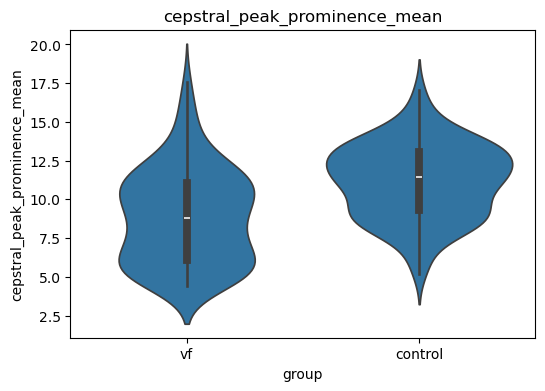

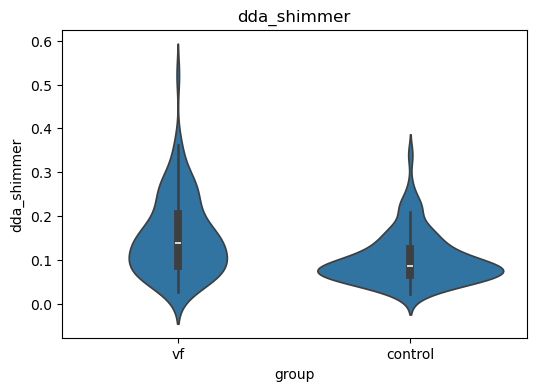

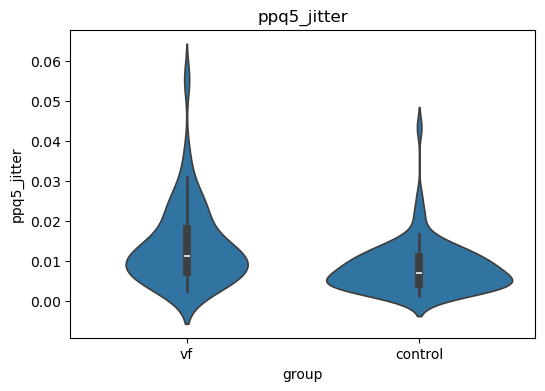

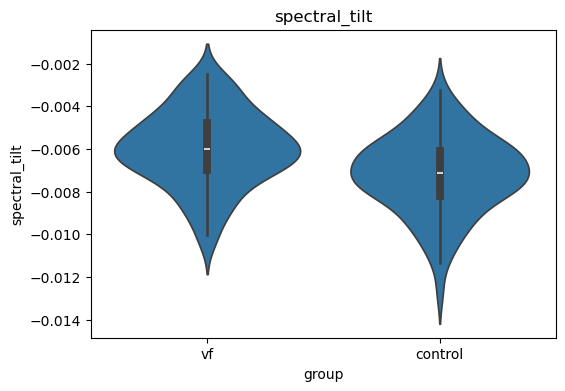

In [372]:
import seaborn as sns

top_features = [
    "cepstral_peak_prominence_mean",
    "dda_shimmer",
    "ppq5_jitter",
    "spectral_tilt"
]

for feat in top_features:

    plt.figure(figsize=(6,4))

    sns.violinplot(
        data=analysis_task_df,
        x="group",
        y=feat
    )

    plt.title(feat)

    plt.show()

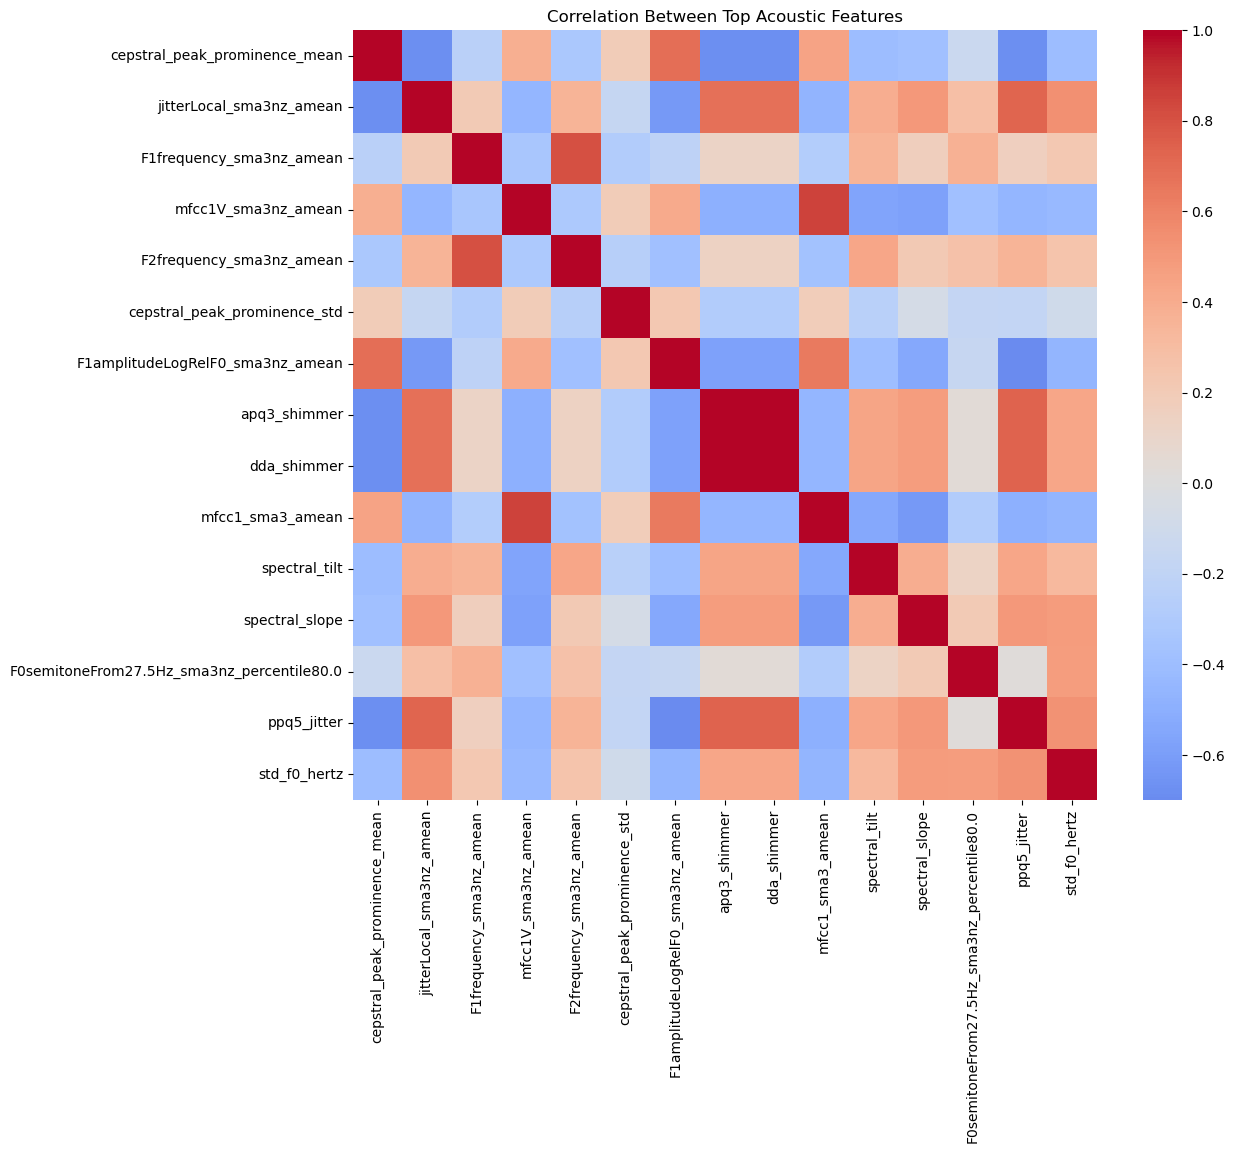

In [373]:
import seaborn as sns

top_feature_names = results_df.head(15)["feature"]

corr = analysis_task_df[
    top_feature_names
].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Top Acoustic Features"
)

plt.show()

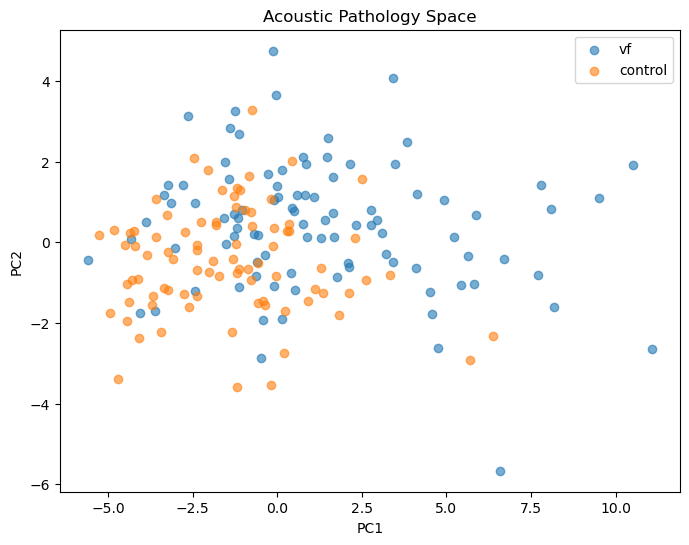

In [374]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

top_feature_names = results_df.head(20)["feature"]

X = analysis_task_df[
    top_feature_names
].fillna(0)

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "group": analysis_task_df["group"].values
})

plt.figure(figsize=(8,6))

for g in plot_df["group"].unique():

    subset = plot_df[
        plot_df["group"] == g
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=g
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Acoustic Pathology Space")

plt.legend()

plt.show()

## Temporal features

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mel = pd.read_parquet("adult/features/torchaudio_mel_spectrogram.parquet")
pitch = pd.read_parquet("adult/features/torchaudio_pitch.parquet")
periodicity = pd.read_parquet("adult/features/sparc_periodicity.parquet")
loudness = pd.read_parquet("adult/features/sparc_loudness.parquet")

print(mel.columns)
print(pitch.columns)
print(periodicity.columns)
print(loudness.columns)

Index(['participant_id', 'session_id', 'task_name', 'mel_spectrogram',
       'n_frames'],
      dtype='str')
Index(['participant_id', 'session_id', 'task_name', 'pitch', 'n_frames'], dtype='str')
Index(['participant_id', 'session_id', 'task_name', 'periodicity', 'n_frames'], dtype='str')
Index(['participant_id', 'session_id', 'task_name', 'loudness', 'n_frames'], dtype='str')


In [381]:
vf_ids = set(analysis_task_df.loc[analysis_task_df["group"] == "vf", "participant_id"])
control_ids = set(analysis_task_df.loc[analysis_task_df["group"] == "control", "participant_id"])

def add_group(df):
    df = df.copy()
    df["group"] = "other"
    df.loc[df["participant_id"].isin(vf_ids), "group"] = "vf"
    df.loc[df["participant_id"].isin(control_ids), "group"] = "control"
    return df[df["group"].isin(["vf", "control"])].copy()

mel_f = add_group(mel)
pitch_f = add_group(pitch)
periodicity_f = add_group(periodicity)
loudness_f = add_group(loudness)

print(mel_f["group"].value_counts())

group
vf         1394
control    1278
Name: count, dtype: int64


In [382]:
print(mel_f.columns)
print(mel_f["task_name"].value_counts().head(30))

Index(['participant_id', 'session_id', 'task_name', 'mel_spectrogram',
       'n_frames', 'group'],
      dtype='str')
task_name
glides-high-to-low                           84
glides-low-to-high                           84
prolonged-vowel                              84
story-recall                                 81
diadochokinesis-buttercup                    80
diadochokinesis-ka                           80
diadochokinesis-pa                           80
diadochokinesis-pataka                       80
diadochokinesis-ta                           80
loudness                                     80
maximum-phonation-time-1                     80
maximum-phonation-time-2                     80
maximum-phonation-time-3                     80
picture-description                          80
rainbow-passage                              80
respiration-and-cough-breath-1               80
respiration-and-cough-breath-2               80
respiration-and-cough-cough-1                80
respira

In [383]:
selected_tasks = [
    "maximum-phonation-time",
    "maximum-phonation-time-v2",
    "prolonged-vowel"
]

mel_task = mel_f[mel_f["task_name"].isin(selected_tasks)].copy()
pitch_task = pitch_f[pitch_f["task_name"].isin(selected_tasks)].copy()
periodicity_task = periodicity_f[periodicity_f["task_name"].isin(selected_tasks)].copy()
loudness_task = loudness_f[loudness_f["task_name"].isin(selected_tasks)].copy()

print(mel_task["task_name"].value_counts())
print(mel_task["group"].value_counts())

task_name
prolonged-vowel    84
Name: count, dtype: int64
group
vf         43
control    41
Name: count, dtype: int64


In [384]:
mel_array_cols = [
    c for c in mel_task.columns
    if "mel" in c.lower() or "spectrogram" in c.lower()
]

mel_array_cols

['mel_spectrogram']

In [387]:
row = mel_task.iloc[0]

print(type(row["mel_spectrogram"]))
print(row["mel_spectrogram"])

<class 'numpy.ndarray'>
[array([5.4883e-01, 5.7422e-01, 7.3340e-01, 7.5586e-01, 1.5295e-01,
        6.3400e-03, 1.9035e-03, 7.1533e-02, 1.4722e-01, 2.9297e-02,
        1.4076e-02, 4.0588e-02, 8.8882e-03, 1.9153e-01, 7.0374e-02,
        1.8854e-03, 1.5356e-01, 9.7412e-02, 3.9307e-02, 3.8635e-02,
        6.5002e-03, 2.1362e-02, 8.5510e-02, 4.0388e-04, 5.7770e-02,
        1.1383e-02, 1.4702e-02, 3.4698e-02, 1.1200e-01, 9.3231e-03,
        1.1673e-02, 2.3666e-02, 6.8130e-03, 3.9177e-03, 6.5460e-03,
        5.1041e-03, 1.2573e-02, 6.1989e-04, 1.5312e-02, 3.6163e-03,
        5.4382e-02, 8.6487e-02, 2.1149e-02, 8.1604e-02, 2.0361e-01,
        9.2712e-02, 5.3680e-02, 1.3077e-02, 7.1411e-02, 1.4175e-02,
        3.8116e-02, 1.0333e-01, 3.7365e-03, 1.5881e-01, 4.6265e-02,
        3.8128e-03, 7.8735e-02, 1.0449e-01, 7.5500e-02, 6.4392e-02,
        3.4302e-02, 1.4160e-01, 2.5977e-01, 3.2463e-03, 4.8340e-02,
        2.5162e-02, 1.1652e-01, 8.3771e-03, 6.4201e-03, 7.5562e-02,
        4.9164e-02, 8.66

(60, 562) float64


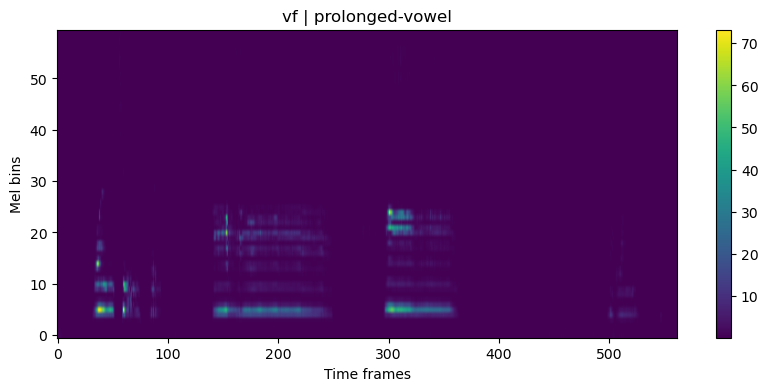

In [388]:
import numpy as np
import matplotlib.pyplot as plt

def to_numeric_array(x):
    arr = np.array(x)

    # If it is nested object arrays/lists, force conversion
    arr = np.asarray(arr.tolist() if arr.dtype == object else arr, dtype=float)

    return arr

row = mel_task.iloc[0]
x = to_numeric_array(row["mel_spectrogram"])

print(x.shape, x.dtype)

plt.figure(figsize=(10, 4))
plt.imshow(x, aspect="auto", origin="lower")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.title(f"{row['group']} | {row['task_name']}")
plt.colorbar()
plt.show()

In [389]:
import numpy as np

def parse_temporal_array(x):

    # Convert nested lists/object arrays safely
    arr = np.array(x)

    if arr.dtype == object:
        arr = np.asarray(arr.tolist(), dtype=float)

    else:
        arr = arr.astype(float)

    return arr

In [390]:
import numpy as np
import matplotlib.pyplot as plt

def parse_temporal_array(x):
    arr = np.array(x)

    if arr.dtype == object:
        arr = np.asarray(arr.tolist(), dtype=float)
    else:
        arr = arr.astype(float)

    return arr


def pad_or_crop_spec(x, target_len=400):
    x = parse_temporal_array(x)

    # Ensure shape is mel_bins x time
    if x.ndim == 1:
        raise ValueError(f"Expected 2D spectrogram, got shape {x.shape}")

    if x.shape[0] != 60 and x.shape[1] == 60:
        x = x.T

    if x.shape[1] > target_len:
        return x[:, :target_len]

    pad_len = target_len - x.shape[1]

    return np.pad(
        x,
        ((0, 0), (0, pad_len)),
        mode="constant"
    )


def pad_or_crop_1d(x, target_len=400):
    x = parse_temporal_array(x).flatten()

    if len(x) > target_len:
        return x[:target_len]

    return np.pad(
        x,
        (0, target_len - len(x)),
        mode="constant"
    )

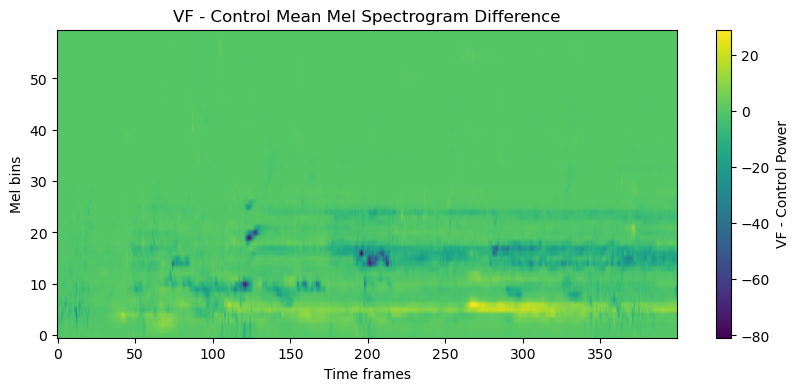

In [391]:
TARGET_LEN = 400
MEL_COL = "mel_spectrogram"

vf_specs = np.stack([
    pad_or_crop_spec(x, TARGET_LEN)
    for x in mel_task.loc[mel_task["group"] == "vf", MEL_COL]
])

ctrl_specs = np.stack([
    pad_or_crop_spec(x, TARGET_LEN)
    for x in mel_task.loc[mel_task["group"] == "control", MEL_COL]
])

vf_mean = vf_specs.mean(axis=0)
ctrl_mean = ctrl_specs.mean(axis=0)

diff = vf_mean - ctrl_mean

plt.figure(figsize=(10, 4))
plt.imshow(diff, aspect="auto", origin="lower")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.title("VF - Control Mean Mel Spectrogram Difference")
plt.colorbar(label="VF - Control Power")
plt.show()

In [392]:
def plot_mean_trajectory(df, value_col, title, target_len=400):
    vf = np.stack([
        pad_or_crop_1d(x, target_len)
        for x in df.loc[df["group"] == "vf", value_col]
    ])

    ctrl = np.stack([
        pad_or_crop_1d(x, target_len)
        for x in df.loc[df["group"] == "control", value_col]
    ])

    vf_mean = vf.mean(axis=0)
    ctrl_mean = ctrl.mean(axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(ctrl_mean, label="Control")
    plt.plot(vf_mean, label="Vocal Fold Paralysis")
    plt.xlabel("Time frames")
    plt.ylabel(value_col)
    plt.title(title)
    plt.legend()
    plt.show()

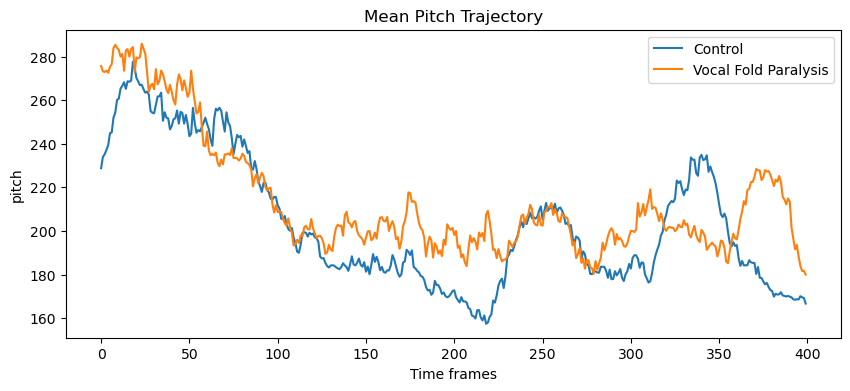

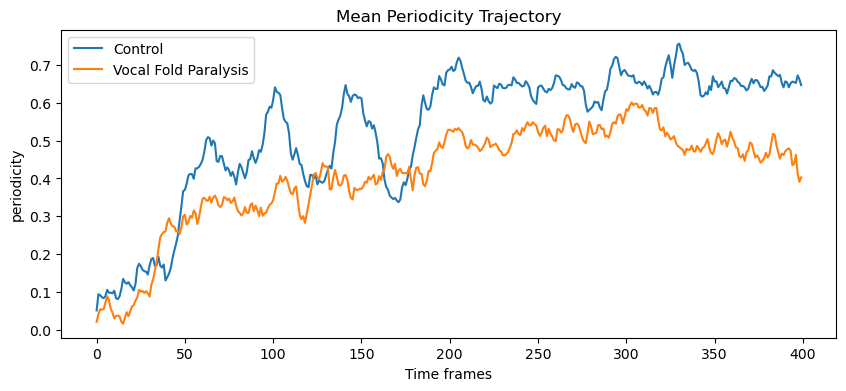

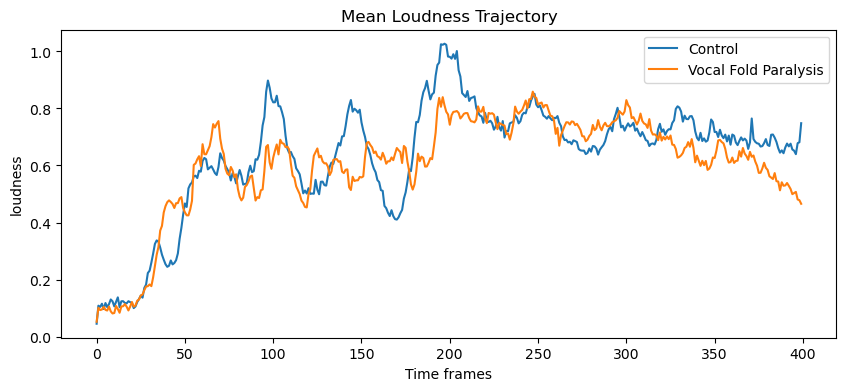

In [393]:
plot_mean_trajectory(pitch_task, "pitch", "Mean Pitch Trajectory")
plot_mean_trajectory(periodicity_task, "periodicity", "Mean Periodicity Trajectory")
plot_mean_trajectory(loudness_task, "loudness", "Mean Loudness Trajectory")

In [394]:
def temporal_summary(x):
    x = parse_temporal_array(x).flatten()
    x = x[np.isfinite(x)]

    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "range": np.max(x) - np.min(x),
        "slope": np.polyfit(np.arange(len(x)), x, 1)[0] if len(x) > 1 else np.nan,
        "cv": np.std(x) / np.mean(x) if np.mean(x) != 0 else np.nan,
    }

In [395]:
PITCH_COL = "pitch"  # change if your column name differs

pitch_summaries = []

for _, row in pitch_task.iterrows():
    stats = temporal_summary(row[PITCH_COL])
    stats["participant_id"] = row["participant_id"]
    stats["group"] = row["group"]
    stats["task_name"] = row["task_name"]
    pitch_summaries.append(stats)

pitch_summary_df = pd.DataFrame(pitch_summaries)

pitch_summary_df.groupby("group").describe()

mean                                                             \
        count        mean        std         min         25%         50%   
group                                                                      
control  41.0  179.302269  46.454808  104.756010  147.679752  171.365818   
vf       43.0  201.526124  44.425171  124.321593  177.195048  202.444836   

                                  std             ...     slope            \
                75%         max count       mean  ...       75%       max   
group                                             ...                       
control  211.292177  311.721098  41.0  71.870873  ...  0.020624  0.239088   
vf       230.348471  386.560901  43.0  81.693129  ...  0.063062  0.215451   

           cv                                                              \
        count      mean       std       min       25%       50%       75%   
group                                                                       
control  41.0  0.384964  0.172040  0.049207  0.284756  0.406967  0.495698   
vf       43.0  0.403003  0.128332  0.136123  0.327586  0.410705  0.471526   

                   
              max  
group              
control  0.760462  
vf       0.691199  

[2 rows x 40 columns]

In [396]:
from scipy.stats import ttest_ind

for col in ["mean", "std", "range", "slope", "cv"]:
    vf = pitch_summary_df.loc[pitch_summary_df["group"] == "vf", col].dropna()
    ctrl = pitch_summary_df.loc[pitch_summary_df["group"] == "control", col].dropna()

    t, p = ttest_ind(vf, ctrl, equal_var=False)

    d = (vf.mean() - ctrl.mean()) / np.sqrt((vf.var() + ctrl.var()) / 2)

    print(col, "p=", p, "cohen_d=", d)

mean p= 0.027897186877724967 cohen_d= 0.48895949205240175
std p= 0.20879363245280932 cohen_d= 0.2775309567432418
range p= 0.042407379865717985 cohen_d= 0.4557474558207118
slope p= 0.2510787675634076 cohen_d= 0.2525022056499169
cv p= 0.58896958793432 cohen_d= 0.11886163930374752


In [397]:
def summarize_temporal_df(df, value_col, name):
    rows = []

    for _, row in df.iterrows():
        stats = temporal_summary(row[value_col])
        stats["participant_id"] = row["participant_id"]
        stats["group"] = row["group"]
        stats["task_name"] = row["task_name"]
        stats["feature_family"] = name
        rows.append(stats)

    return pd.DataFrame(rows)

In [398]:
PERIODICITY_COL = "periodicity"  # change if needed
LOUDNESS_COL = "loudness"        # change if needed

periodicity_summary_df = summarize_temporal_df(
    periodicity_task,
    PERIODICITY_COL,
    "periodicity"
)

loudness_summary_df = summarize_temporal_df(
    loudness_task,
    LOUDNESS_COL,
    "loudness"
)

pitch_summary_df["feature_family"] = "pitch"

temporal_summary_df = pd.concat(
    [
        pitch_summary_df,
        periodicity_summary_df,
        loudness_summary_df
    ],
    ignore_index=True
)

temporal_summary_df.head()

,mean,std,range,slope,cv,participant_id,group,task_name,feature_family
0,210.612207,60.896475,382.5625,0.000886,0.289140,134175,vf,prolonged-vowel,pitch
1,209.510330,85.263695,398.7500,0.004050,0.406967,141723,control,prolonged-vowel,pitch
2,210.831699,111.171298,404.7500,0.071248,0.527299,146530,vf,prolonged-vowel,pitch
3,230.692195,57.790384,367.9375,-0.022212,0.250509,157641,vf,prolonged-vowel,pitch
4,244.640442,186.039712,395.8750,-0.160838,0.760462,167292,control,prolonged-vowel,pitch


In [399]:
from scipy.stats import ttest_ind
import numpy as np

rows = []

for family in temporal_summary_df["feature_family"].unique():
    sub = temporal_summary_df[
        temporal_summary_df["feature_family"] == family
    ]

    for metric in ["mean", "std", "range", "slope", "cv"]:
        vf = sub.loc[sub["group"] == "vf", metric].dropna()
        ctrl = sub.loc[sub["group"] == "control", metric].dropna()

        if len(vf) > 5 and len(ctrl) > 5:
            t, p = ttest_ind(vf, ctrl, equal_var=False)

            pooled_std = np.sqrt((vf.var() + ctrl.var()) / 2)
            d = (vf.mean() - ctrl.mean()) / pooled_std if pooled_std > 0 else np.nan

            rows.append({
                "feature_family": family,
                "metric": metric,
                "vf_mean": vf.mean(),
                "control_mean": ctrl.mean(),
                "cohen_d": d,
                "abs_cohen_d": abs(d),
                "p_value": p,
                "vf_n": len(vf),
                "control_n": len(ctrl)
            })

temporal_results_df = pd.DataFrame(rows).sort_values(
    "abs_cohen_d",
    ascending=False
)

temporal_results_df

,feature_family,metric,vf_mean,control_mean,cohen_d,abs_cohen_d,p_value,vf_n,control_n
5,periodicity,mean,0.424286,0.566795,-0.792287,0.792287,0.000484,43,41
9,periodicity,cv,1.036541,0.784528,0.595954,0.595954,0.007816,43,41
0,pitch,mean,201.526124,179.302269,0.488959,0.488959,0.027897,43,41
2,pitch,range,355.341570,310.515244,0.455747,0.455747,0.042407,43,41
11,loudness,std,0.542380,0.507161,0.376890,0.376890,0.087810,43,41
14,loudness,cv,0.955237,0.849247,0.365315,0.365315,0.097322,43,41
1,pitch,std,81.693129,71.870873,0.277531,0.277531,0.208794,43,41
10,loudness,mean,0.595757,0.618900,-0.277069,0.277069,0.207132,43,41
7,periodicity,range,0.956000,0.960598,-0.259740,0.259740,0.235368,43,41
3,pitch,slope,-0.007364,-0.033460,0.252502,0.252502,0.251079,43,41


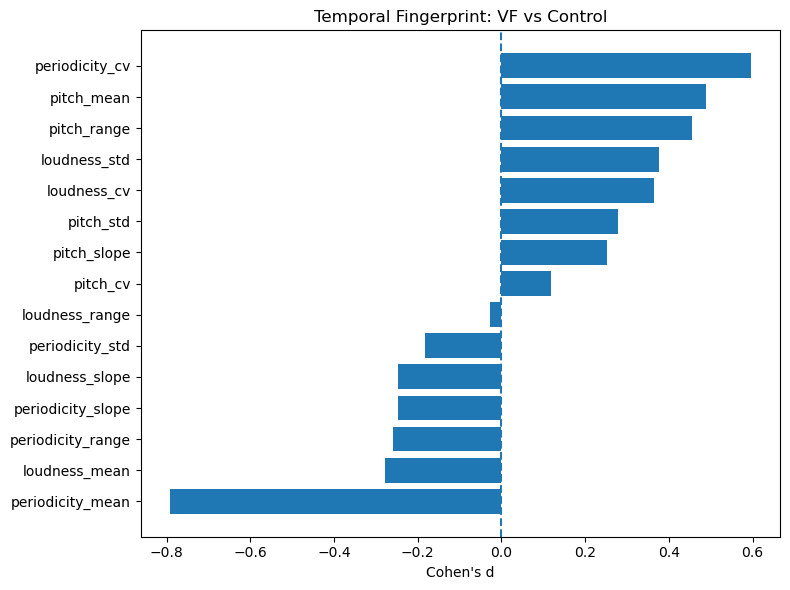

In [400]:
top = temporal_results_df.head(20).sort_values("cohen_d")

plt.figure(figsize=(8, 6))
plt.barh(
    top["feature_family"] + "_" + top["metric"],
    top["cohen_d"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Cohen's d")
plt.title("Temporal Fingerprint: VF vs Control")
plt.tight_layout()
plt.show()

## Mel spectogram

In [401]:
TARGET_LEN = 400
MEL_COL = "mel_spectrogram"

vf_specs = np.stack([
    pad_or_crop_spec(x, TARGET_LEN)
    for x in mel_task.loc[mel_task["group"] == "vf", MEL_COL]
])

ctrl_specs = np.stack([
    pad_or_crop_spec(x, TARGET_LEN)
    for x in mel_task.loc[mel_task["group"] == "control", MEL_COL]
])

vf_mean = vf_specs.mean(axis=0)
ctrl_mean = ctrl_specs.mean(axis=0)
diff = vf_mean - ctrl_mean

print(vf_specs.shape, ctrl_specs.shape)

(43, 60, 400) (41, 60, 400)


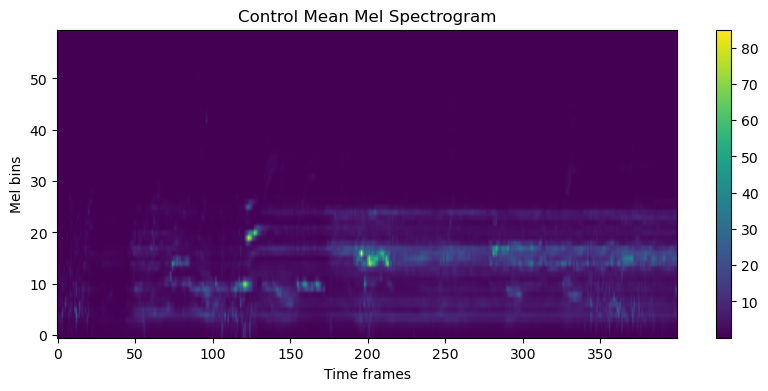

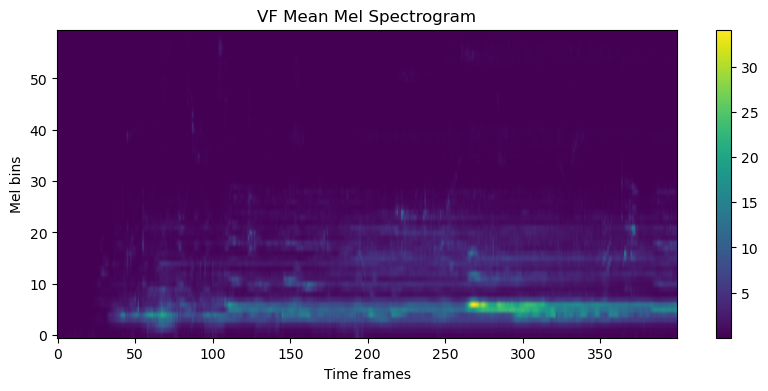

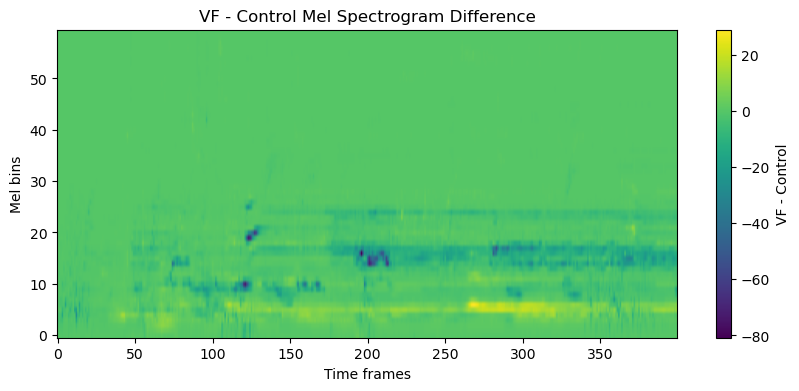

In [402]:
plt.figure(figsize=(10, 4))
plt.imshow(ctrl_mean, aspect="auto", origin="lower")
plt.title("Control Mean Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(vf_mean, aspect="auto", origin="lower")
plt.title("VF Mean Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(diff, aspect="auto", origin="lower")
plt.title("VF - Control Mel Spectrogram Difference")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar(label="VF - Control")
plt.show()